In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 한강

In [2]:
HAN_CSV_PATH = (
    "raw/Han_2019.csv",
    "raw/Han_2020.csv",
    "raw/Han_2021.csv",
    "raw/Han_2022.csv",
    "raw/Han_2023.csv"
)

### 금강

In [3]:
GEUM_CSV_PATH = (
    "raw/Geum_2019-2020.csv",
    "raw/Geum_2021.csv",
    "raw/Geum_2022.csv",
    "raw/Geum_2023.csv"
)

### 낙동강

In [4]:
NAKDONG_CSV_PATH = (
    "raw/Nakdong_2019.csv",
    "raw/Nakdong_2020.csv",
    "raw/Nakdong_2021.csv",
    "raw/Nakdong_2022.csv",
    "raw/Nakdong_2023.csv"
)

### 영산강섬진강

In [5]:
YEONGSANSEOMJIN_CSV_PATH = (
    "raw/YeongsanSeomjin_2019-2020.csv",
    "raw/YeongsanSeomjin_2021.csv",
    "raw/YeongsanSeomjin_2022.csv",
    "raw/YeongsanSeomjin_2023.csv"
)

In [6]:
RIVER_CSV_PATH = {
    "raw/Han.csv": HAN_CSV_PATH,
    "raw/Geum.csv": GEUM_CSV_PATH,
    "raw/Nakdong.csv": NAKDONG_CSV_PATH,
    "raw/YeongsanSeomjin.csv": YEONGSANSEOMJIN_CSV_PATH
}

### 한국환경공단 공공하수처리시설 현황

In [7]:
PSTF_CSV_PATH = {
    2019: "raw/Public Sewage Treatment Facility_2019.csv",
    2020: "raw/Public Sewage Treatment Facility_2020.csv",
    2021: "raw/Public Sewage Treatment Facility_2021.csv",
    2022: "raw/Public Sewage Treatment Facility_2022.csv",
    2023: "raw/Public Sewage Treatment Facility_2023.csv"
}

In [8]:
from functools import reduce
def process_and_merge_csv(file_paths):
    df_list = []
    
    for path in file_paths:
        df = pd.read_csv(path, encoding="cp949")
        
        cols = list(df.columns)
        cols[0:4] = ["수계별(1)", "수계별(2)", "수계별(3)", "항목"]
        df.columns = cols

        df.loc[df["항목"].str.contains("수온", na=False), "항목"] = "Temp"
        df.loc[df["항목"].str.contains("TOC", na=False), "항목"] = "TOC"
        df.loc[df["항목"].str.contains("유량", na=False), "항목"] = "Flow"

        df_list.append(df)

    merged_df = reduce(lambda left, right: pd.merge(left, right, on=["수계별(1)", "수계별(2)", "수계별(3)", "항목"], how="outer"), df_list)

    return merged_df

for save_path, paths in RIVER_CSV_PATH.items():
    final_df = process_and_merge_csv(paths)
    final_df.to_csv(save_path, index=False, encoding="cp949")

print("csv 파일 통합 완료")

csv 파일 통합 완료


In [9]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [10]:
# 수계별 폐수물 방류량

lst_pstf = []
for year, path in PSTF_CSV_PATH.items():
    df = pd.read_csv(path, encoding="cp949")

    df["Year"] = year
    lst_pstf.append(df)

df = pd.concat(lst_pstf, ignore_index=True)
df_waste = df.groupby(["Year", "수계"])["방류량"].sum().reset_index()

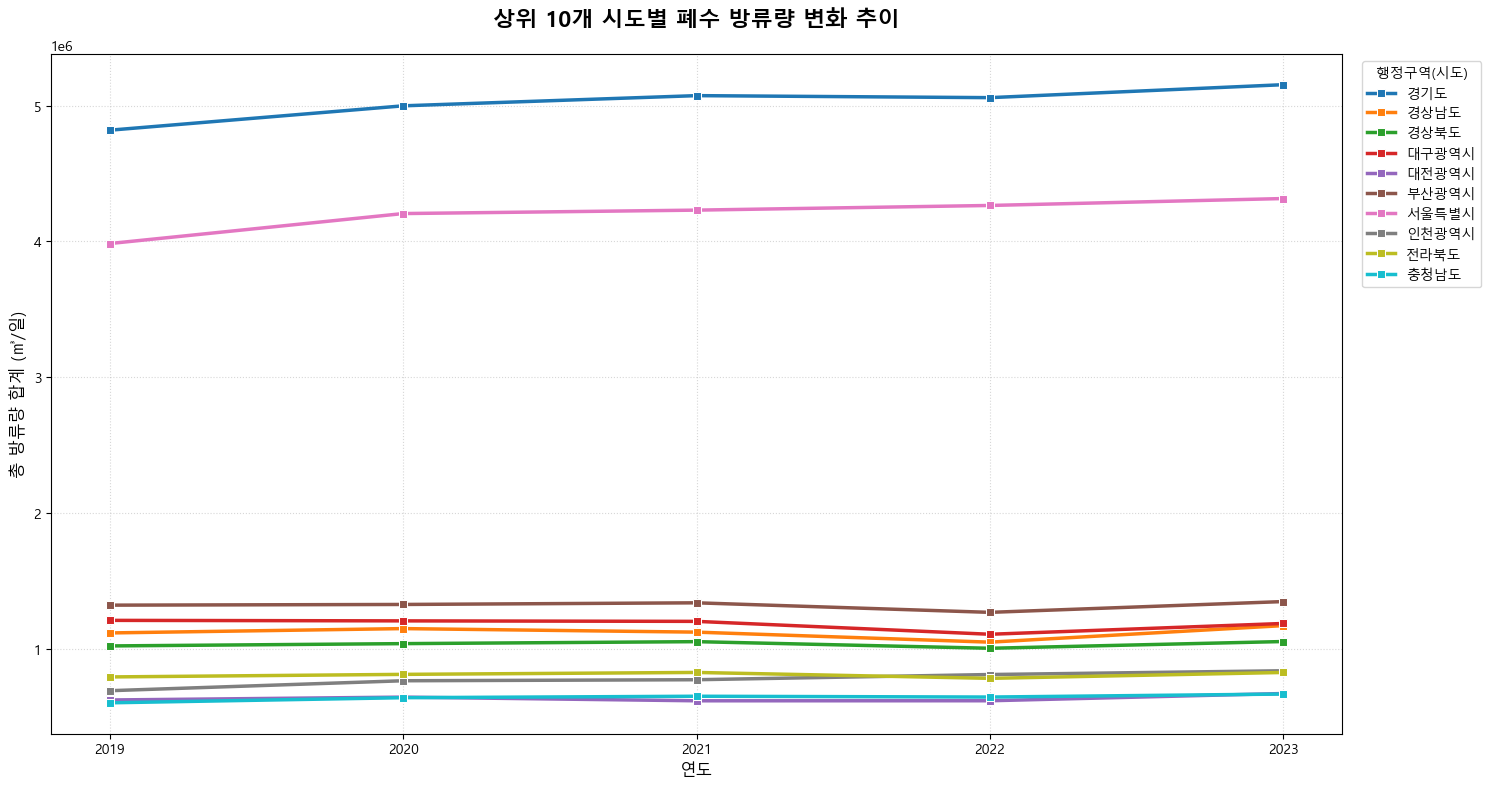

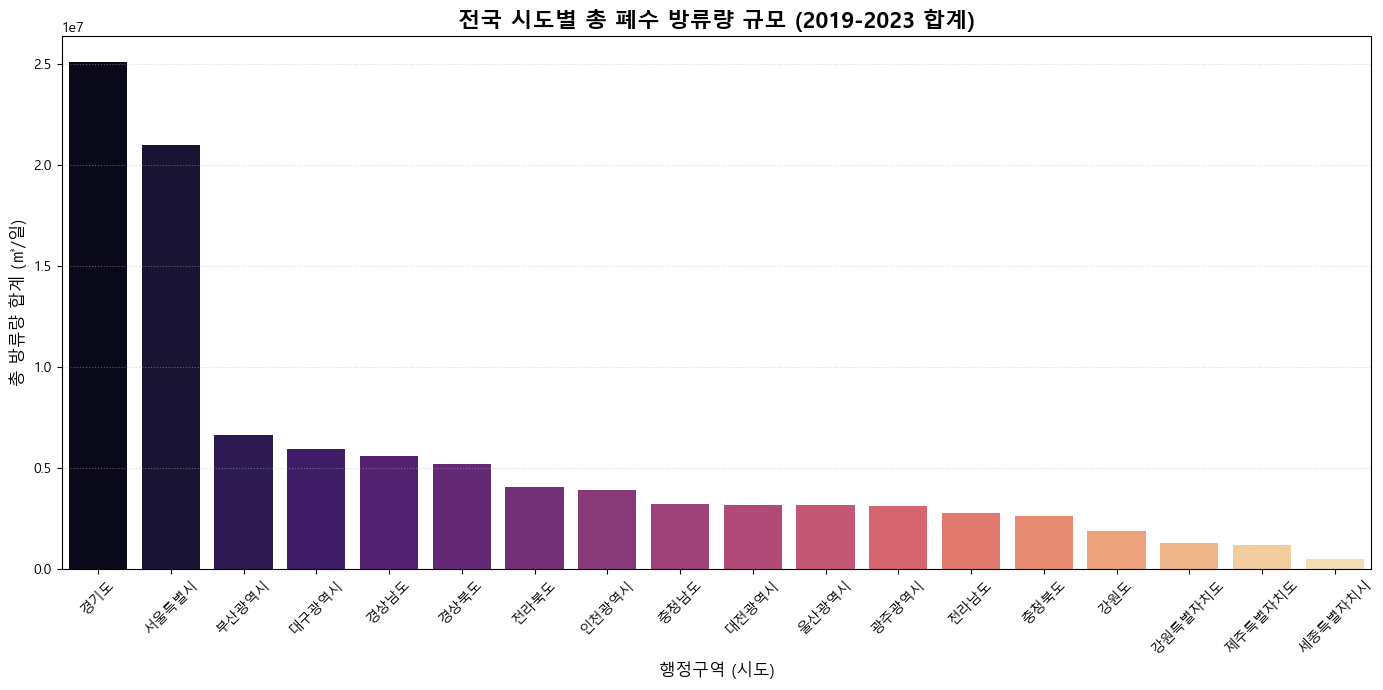

In [26]:
# 1. 데이터 통합 및 '방류량' 숫자 변환 (기존 로직 포함)
lst_pstf = []
for year, path in PSTF_CSV_PATH.items():
    try:
        df_temp = pd.read_csv(path, encoding="cp949")
    except UnicodeDecodeError:
        df_temp = pd.read_csv(path, encoding="utf-8")
    
    # 방류량 데이터 정제: 결측치 제거 및 숫자 변환
    df_temp["방류량"] = pd.to_numeric(df_temp["방류량"], errors='coerce')
    df_temp["Year"] = year
    lst_pstf.append(df_temp)

df_all_pstf = pd.concat(lst_pstf, ignore_index=True)

# 2. 지역별(시도) 통계 데이터 생성
# 연도별/지역별 합계
df_city_trend = df_all_pstf.groupby(["Year", "시도"])["방류량"].sum().reset_index()

# 전체 기간 지역별 총합 (정렬용)
df_city_total = df_all_pstf.groupby("시도")["방류량"].sum().sort_values(ascending=False).reset_index()

# --- 시각화 ---
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 그래프 1: 주요 지역별 연도별 방류량 추이
plt.figure(figsize=(15, 8))
# 상위 10개 지역만 필터링해서 그리면 그래프가 더 깔끔합니다 (전체 보고 싶으시면 filter 제거)
top_cities = df_city_total['시도'].head(10).tolist()
df_top_trend = df_city_trend[df_city_trend['시도'].isin(top_cities)]

sns.lineplot(
    data=df_top_trend, 
    x='Year', 
    y='방류량', 
    hue='시도', 
    marker='s', 
    linewidth=2.5
)

plt.title("상위 10개 시도별 폐수 방류량 변화 추이", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("연도", fontsize=12)
plt.ylabel("총 방류량 합계 (㎥/일)", fontsize=12)
plt.xticks(df_city_trend['Year'].unique())
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="행정구역(시도)")
plt.tight_layout()
plt.show()

# 그래프 2: 지역별 총 방류량 규모 비교 (FutureWarning 해결 버전)
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_city_total, 
    x='시도', 
    y='방류량', 
    hue='시도',       # x축과 동일하게 지정하여 워닝 방지
    palette='magma', 
    legend=False
)

plt.title("전국 시도별 총 폐수 방류량 규모 (2019-2023 합계)", fontsize=16, fontweight='bold')
plt.xlabel("행정구역 (시도)", fontsize=12)
plt.ylabel("총 방류량 합계 (㎥/일)", fontsize=12)
plt.xticks(rotation=45) # 지역명이 겹치지 않게 회전
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
# 강 권역
def get_region(name):
    if '한강' in name or '안성천' in name:
        return '한강'
    elif '낙동강' in name: 
        return '낙동강'
    elif '금강' in name: 
        return '금강'
    elif '영산강' in name: 
        return '영산강'
    elif '섬진강' in name: 
        return '섬진강'
    elif '제주' in name: 
        return '제주도'
    else:
        return '기타'

# 수계별 toc 수치

csv_paths = list(RIVER_CSV_PATH.keys())
csv_lst = []
for path in csv_paths:
    df = pd.read_csv(path, encoding="cp949")
    csv_lst.append(df)

df = pd.concat(csv_lst, ignore_index=True)

date_columns = df.columns[4:] # 0~2 수계, 3 항목 고정, 4부터 날짜

lst_data = []
for col in date_columns:
    df_tmp = df[["수계별(1)", "항목", col]]
    df_tmp.columns = ["수계", "항목", "Value"]
    df_tmp["Date"] = col
    df_tmp["Year"] = int(col[:4])
    df_tmp["Month"] = int(col[5:7])
    df_tmp["Value"] = pd.to_numeric(df_tmp["Value"], errors='coerce')
    df_tmp["권역"] = df_tmp["수계"].apply(get_region)
    #df_tmp["Quarter"] = (df["Month"] - 1) // 1 + 1

    lst_data.append(df_tmp)

df = pd.concat(lst_data, ignore_index=True)

df_toc = df[df["항목"] == "TOC"]
df_toc = df_toc.copy().rename(columns={"Value": "TOC"})
df_flow = df[df["항목"] == "Flow"]
df_flow = df_flow.copy().rename(columns={"Value": "Flow"})
df_temp = df[df["항목"] == "Temp"]
df_temp = df_temp.copy().rename(columns={"Value": "Temp"})

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

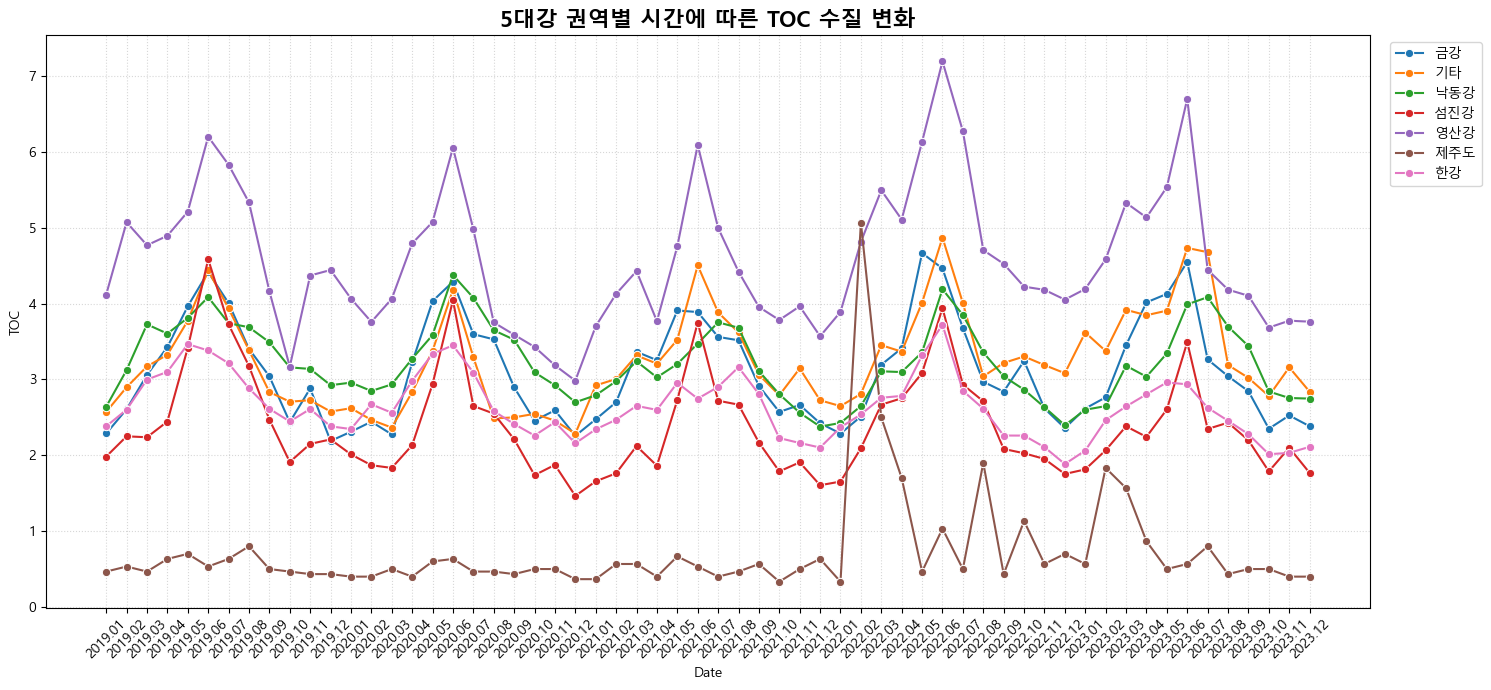

In [21]:
df_toc_avg = df_toc.groupby(["Date", "Year", "Month", "권역"])[["TOC"]].mean().reset_index()

df_toc_avg = df_toc_avg.sort_values(["Year", "Month"])

plt.figure(figsize=(15, 7))
sns.lineplot(
    data=df_toc_avg, 
    x='Date', 
    y='TOC',
    hue='권역', 
    marker='o'
)

plt.title("5대강 권역별 시간에 따른 TOC 수질 변화", fontsize=16, fontweight='bold')
plt.xticks(rotation=45) # 날짜가 겹치지 않게 회전
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

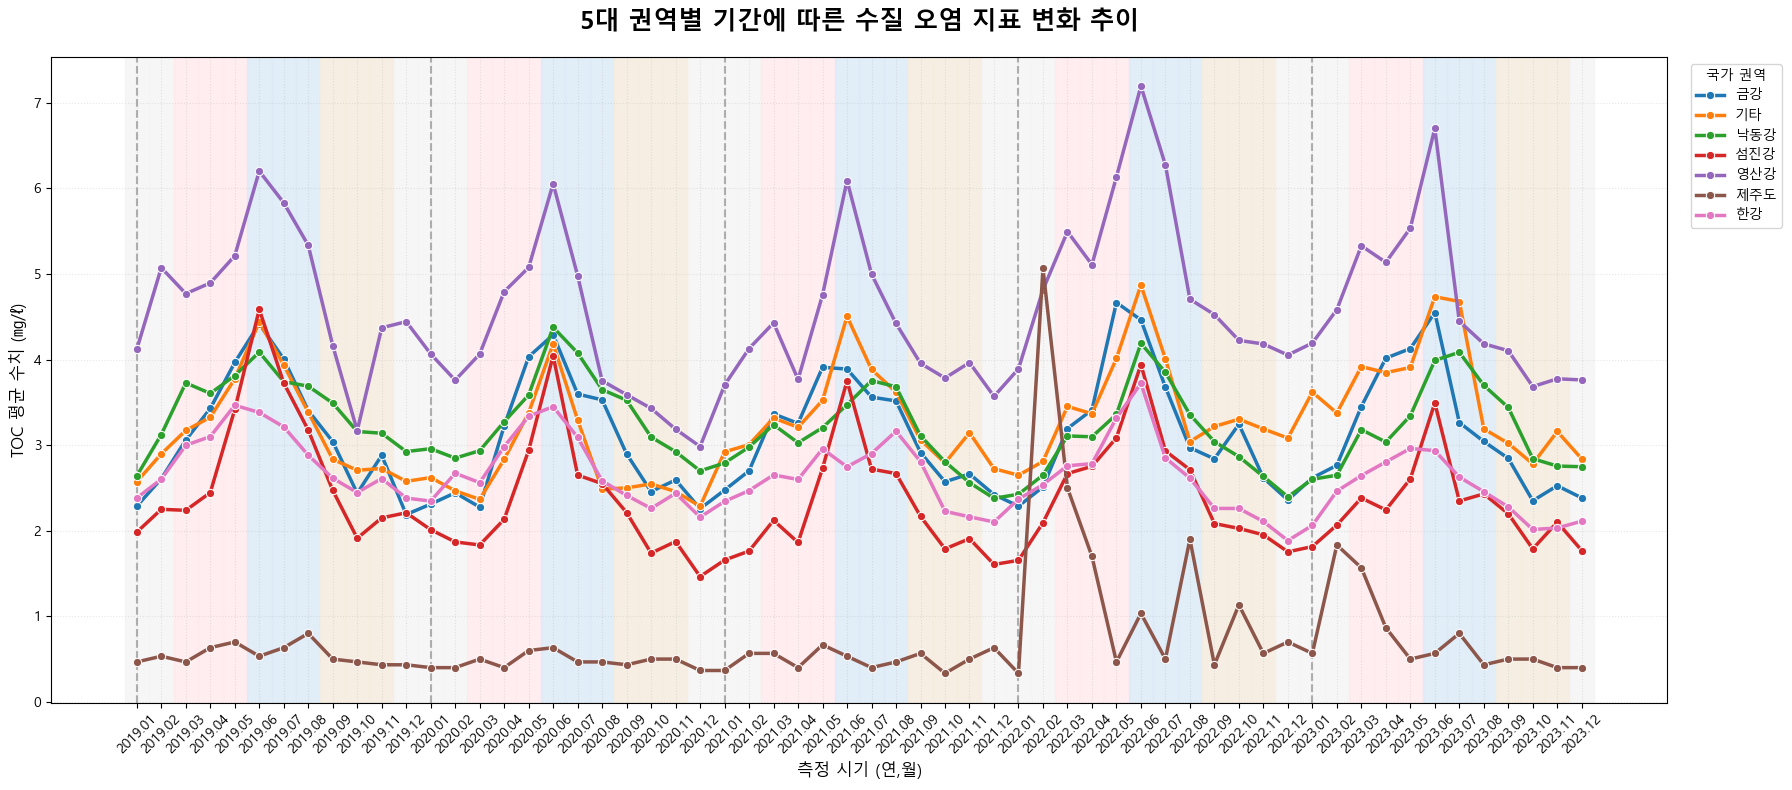

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (기존 로직 유지)
df_region_avg = df_toc.groupby(["Date", "Year", "Month", "권역"])[["TOC"]].mean().reset_index()
df_region_avg = df_region_avg.sort_values(["Year", "Month"])

# 2. 그래프 그리기
plt.figure(figsize=(18, 8))
ax = sns.lineplot(
    data=df_region_avg, 
    x='Date', 
    y='TOC', 
    hue='권역', 
    marker='o', 
    linewidth=2.5,
    zorder=5  # 선이 배경보다 위로 오도록
)

# --- 배경색 및 구분선 최적화 로직 ---

# 모든 날짜 리스트와 인덱스 매핑
all_dates = df_region_avg['Date'].unique().tolist()
date_to_idx = {date: i for i, date in enumerate(all_dates)}

# 계절별 설정 (색상과 투명도 강화)
# 봄(3-5), 여름(6-8), 가을(9-11), 겨울(12-2)
seasons = {
    'spring': {'months': [3, 4, 5], 'color': '#ffebee', 'alpha': 0.9}, 
    'summer': {'months': [6, 7, 8], 'color': '#deebf7', 'alpha': 0.9}, 
    'autumn': {'months': [9, 10, 11], 'color': '#f5eddf', 'alpha': 0.9}, 
    'winter': {'months': [12, 1, 2], 'color': '#f5f5f5', 'alpha': 0.9}
}

for i, date_str in enumerate(all_dates):
    month = int(date_str.split('.')[1])

    # 계절 확인
    curr_season = None
    for s_name, s_info in seasons.items():
        if month in s_info['months']:
            curr_season = s_info
            break
            
    if curr_season:
        # axvspan(시작인덱스, 끝인덱스) - 인덱스 간격을 0.5씩 확장하여 빈틈없이 채움
        plt.axvspan(i - 0.5, i + 0.5, color=curr_season['color'], alpha=curr_season['alpha'], zorder=1)

# 연도별 구분선 추가 (매년 1월 기준)
for i, date_str in enumerate(all_dates):
    if date_str.endswith('.01'):
        plt.axvline(x=i, color='gray', linestyle='--', alpha=0.6, linewidth=1.5, zorder=2)

# --- 그래프 마무리 설정 ---

plt.title("5대 권역별 기간에 따른 수질 오염 지표 변화 추이", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("측정 시기 (연,월)", fontsize=12)
plt.ylabel("TOC 평균 수치 (㎎/ℓ)", fontsize=12)

# X축 레이블 가독성 (데이터가 많으므로 적절히 조절)
plt.xticks(rotation=45)

plt.grid(True, linestyle=':', alpha=0.3, zorder=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="국가 권역")
plt.tight_layout()

plt.show()

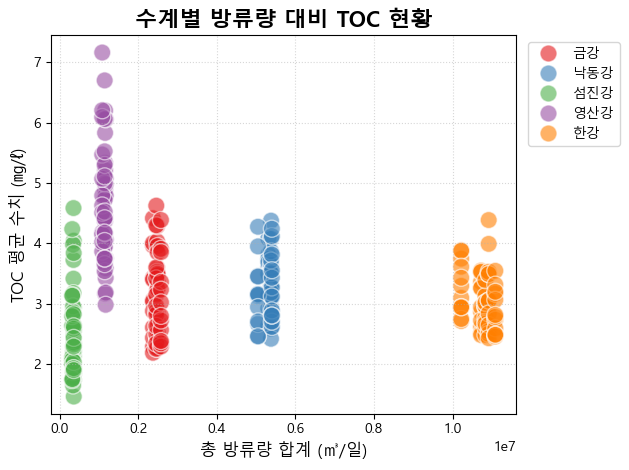

In [14]:
df_q_avg = df_toc.groupby(["Year", "Month", "수계"]).mean(numeric_only = True).reset_index()
df_final_q = pd.merge(df_waste, df_q_avg, on=["Year", "수계"], how="inner")

# 시각화
#plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_final_q, 
    x='방류량', 
    y='TOC', 
    hue='수계',
    s=150,
    palette='Set1',
    alpha=0.6
)

plt.title("수계별 방류량 대비 TOC 현황", fontsize=16, fontweight='bold')
plt.xlabel("총 방류량 합계 (㎥/일)", fontsize=12)
plt.ylabel("TOC 평균 수치 (㎎/ℓ)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)

plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

C:\Users\NT371B5A\AppData\Local\Temp\ipykernel_5764\2066667560.py:61: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\NT371B5A\AppData\Local\Temp\ipykernel_5764\2066667560.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")


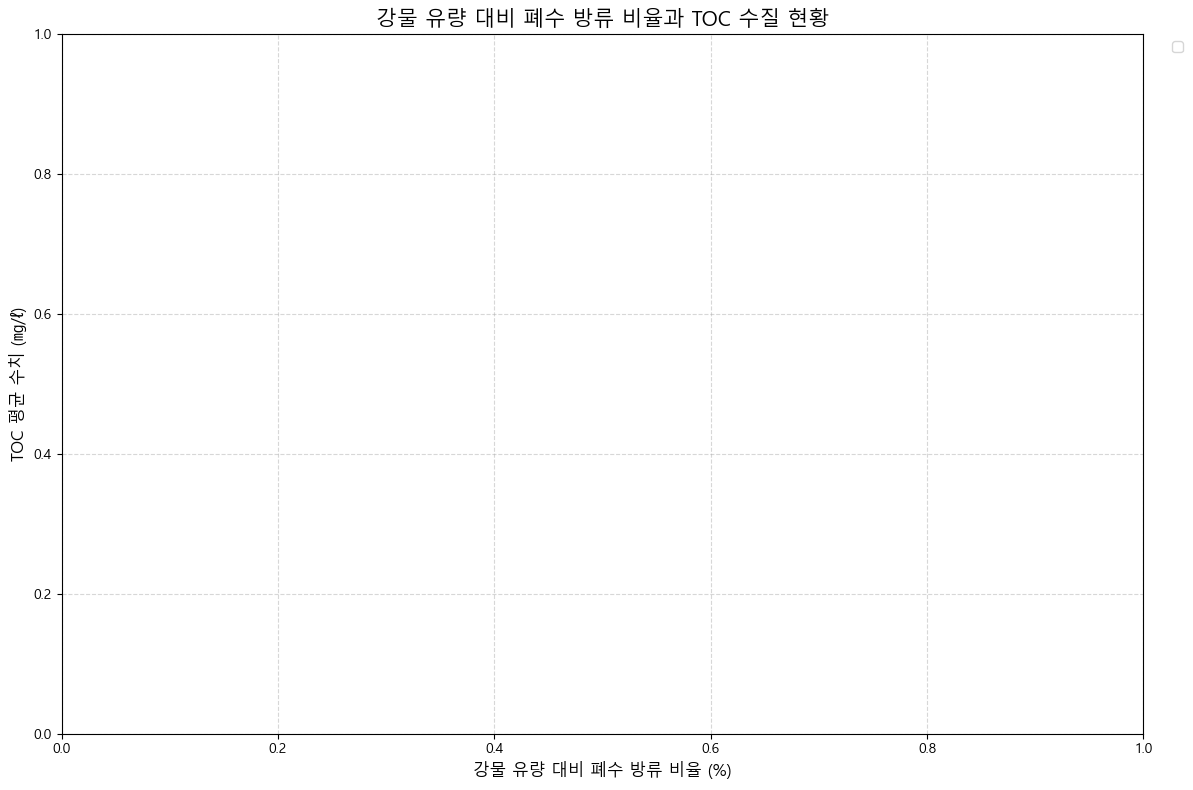

In [17]:
# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 1. 수계별 폐수물 방류량 데이터 통합
pstf_lst = []
for year, path in PSTF_CSV_PATH.items():
    temp = pd.read_csv(path, encoding="cp949")
    temp["Year"] = year
    pstf_lst.append(temp)

df_waste_all = pd.concat(pstf_lst, ignore_index=True)
df_waste = df_waste_all.groupby(["Year", "수계"])["방류량"].sum().reset_index()

# 2. 수계별 수질/유량 데이터 로드
wq_paths = HAN_CSV_PATH + GEUM_CSV_PATH + NAKDONG_CSV_PATH + YEONGSANSEOMJIN_CSV_PATH
wq_lst = []
for path in wq_paths:
    wq_lst.append(pd.read_csv(path, encoding="cp949"))

df_wq = pd.concat(wq_lst, ignore_index=True)
df_toc_raw = df_wq[df_wq["항목"] == "TOC"]
df_flow_raw = df_wq[df_wq["항목"] == "유량"]

date_columns = df_toc_raw.columns[4:]

# 3. TOC 데이터 전처리
lst_toc = []
for col in date_columns:
    df_tmp = df_toc_raw[["수계별(1)", col]].copy()
    df_tmp.columns = ["수계", "TOC"]
    df_tmp["Date"] = col
    lst_toc.append(df_tmp)

df_toc_long = pd.concat(lst_toc, ignore_index=True)
df_toc_long["Year"] = df_toc_long["Date"].str[:4].astype(int)
df_toc_long["TOC"] = pd.to_numeric(df_toc_long["TOC"], errors='coerce')
df_toc_avg = df_toc_long.groupby(["Year", "수계"])["TOC"].mean().reset_index()

# 4. 유량 데이터 전처리
lst_flow = []
for col in date_columns:
    df_tmp = df_flow_raw[["수계별(1)", col]].copy()
    df_tmp.columns = ["수계", "유량"] # 컬럼명 명시
    df_tmp["Date"] = col
    lst_flow.append(df_tmp)

df_flow_long = pd.concat(lst_flow, ignore_index=True)
df_flow_long["Year"] = df_flow_long["Date"].str[:4].astype(int)
df_flow_long["유량"] = pd.to_numeric(df_flow_long["유량"], errors='coerce')
df_flow_avg = df_flow_long.groupby(["Year", "수계"])["유량"].mean().reset_index()

# 5. 데이터 병합
df_final = pd.merge(df_waste, df_toc_avg, on=["Year", "수계"], how="inner")
df_final = pd.merge(df_final, df_flow_avg, on=["Year", "수계"], how="inner")

# 6. 신규 지표: 방류비율 계산
# 하천유량(m3/sec) -> 일일유량(m3/day) 환산 (86400)
df_final['방류비율'] = (df_final['방류량'] / (df_final['유량'] * 864) ** 2) * 100

# 7. 시각화
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_final, 
    x='방류비율', 
    y='TOC', 
    hue='Year',
    style='수계',
    s=200, 
    palette='viridis',
    alpha=0.7
)

plt.title("강물 유량 대비 폐수 방류 비율과 TOC 수질 현황", fontsize=15)
plt.xlabel("강물 유량 대비 폐수 방류 비율 (%)", fontsize=12)
plt.ylabel("TOC 평균 수치 (㎎/ℓ)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()) * 100



C:\Users\NT371B5A\AppData\Local\Temp\ipykernel_5764\1459060001.py:83: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\NT371B5A\AppData\Local\Temp\ipykernel_5764\1459060001.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


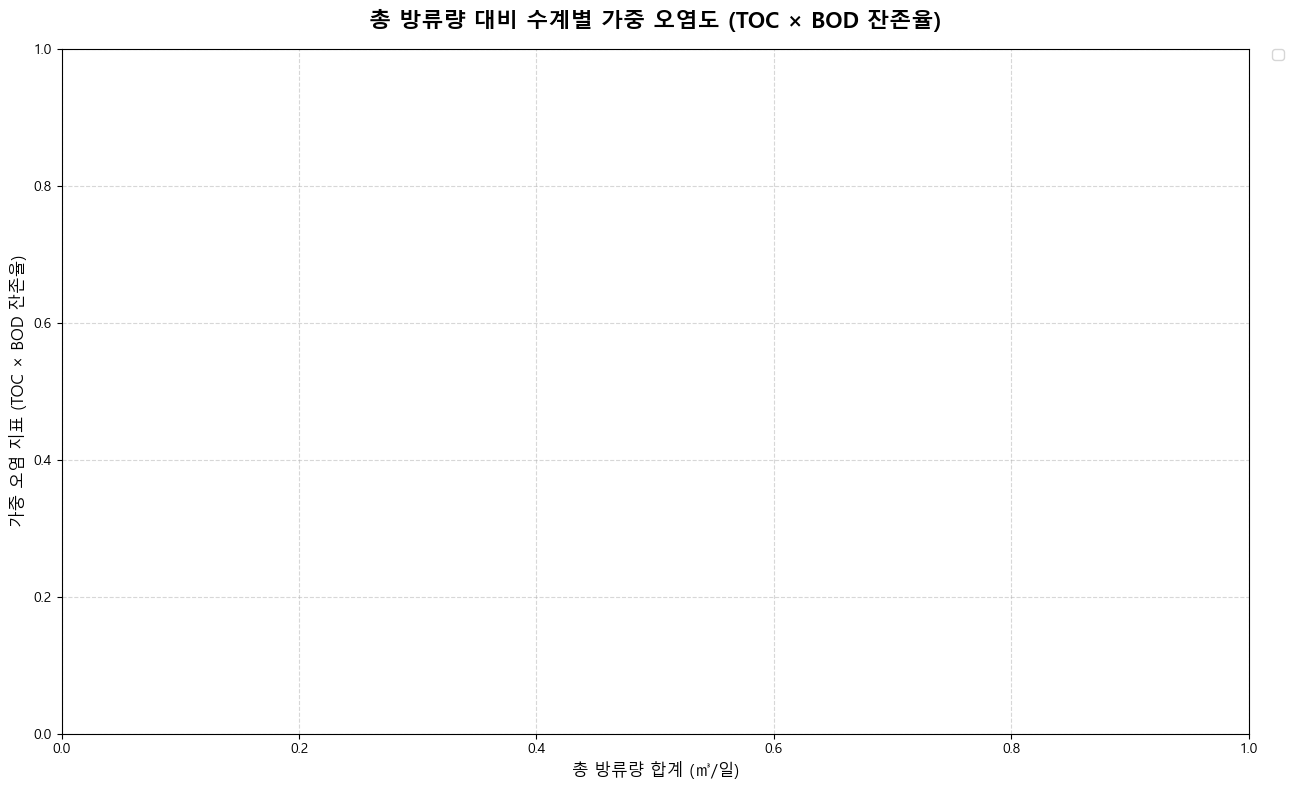

In [18]:
# 0. 환경 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 1. 하수처리시설 데이터 (방류량 및 BOD 잔존율 계산)
# ==========================================
pstf_lst = []
for year, path in PSTF_CSV_PATH.items():
    try:
        df_temp = pd.read_csv(path, encoding="cp949")
    except:
        df_temp = pd.read_csv(path, encoding="utf-8")
        
    df_temp["Year"] = year
    df_temp.columns = df_temp.columns.str.strip().str.replace('\s+', ' ', regex=True).str.replace('\n', '')

    def find_col_by_keywords(df, keywords):
        for col in df.columns:
            if all(k in col for k in keywords):
                return col
        return None

    c_in_bod = find_col_by_keywords(df_temp, ['유입', 'BOD'])
    c_out_bod = find_col_by_keywords(df_temp, ['방류', 'BOD'])
    c_flow = find_col_by_keywords(df_temp, ['방류량']) or '방류량'

    if c_in_bod and c_out_bod and c_flow:
        for c in [c_in_bod, c_out_bod, c_flow]:
            df_temp[c] = pd.to_numeric(df_temp[c].astype(str).str.replace(',', ''), errors='coerce').fillna(0)

        # [핵심] 질문자님이 도출하신 'BOD 잔존율(미처리율)' 계산 (2.9~5.2 수치)
        df_temp['BOD_잔존율'] = (df_temp[c_out_bod] / df_temp[c_in_bod].replace(0, np.nan)) * 100
        
        res = df_temp[['Year', '수계', c_flow, 'BOD_잔존율']].copy()
        res.columns = ['Year', '수계', '방류량', 'BOD_잔존율']
        pstf_lst.append(res)

df_waste_all = pd.concat(pstf_lst, ignore_index=True)
df_waste_agg = df_waste_all.groupby(["Year", "수계"]).agg({
    '방류량': 'sum',
    'BOD_잔존율': 'mean'
}).reset_index()

# ==========================================
# 2. 수계별 수질 데이터 (TOC) 추출
# ==========================================
wq_paths = HAN_CSV_PATH + GEUM_CSV_PATH + NAKDONG_CSV_PATH + YEONGSANSEOMJIN_CSV_PATH
wq_lst = []
for path in wq_paths:
    df = pd.read_csv(path, encoding="cp949")
    wq_lst.append(df)

df_wq = pd.concat(wq_lst, ignore_index=True)
df_toc = df_wq[df_wq["항목"] == "TOC"]

date_columns = df_toc.columns[4:] 

lst_data = []
for col in date_columns:
    df_tmp = df_toc[["수계별(1)", col]].copy()
    df_tmp.columns = ["수계", "TOC"]
    df_tmp["Date"] = col
    lst_data.append(df_tmp)

df_toc_all = pd.concat(lst_data, ignore_index=True)
df_toc_all["Year"] = df_toc_all["Date"].str[:4].astype(int)
df_toc_all["TOC"] = pd.to_numeric(df_toc_all["TOC"], errors='coerce')
df_avg = df_toc_all.groupby(["Year", "수계"])["TOC"].mean().reset_index()

# ==========================================
# 3. 데이터 통합 및 새로운 지표(TOC * BOD 잔존율) 생성
# ==========================================
df_final = pd.merge(df_waste_agg, df_avg, on=["Year", "수계"], how="inner")

# 요청하신 수식 적용: 하천 TOC × 하수처리장 BOD 미처리율
df_final['가중오염지표'] = df_final['TOC'] / df_final['BOD_잔존율'] ** 2

# ==========================================
# 4. 시각화 (Scatter Plot)
# ==========================================
plt.figure(figsize=(13, 8))
sns.scatterplot(
    data=df_final, 
    x='방류량', 
    y='가중오염지표', 
    hue='Year',
    style='수계',
    s=250, 
    palette='viridis',
    alpha=0.8
)

plt.title("총 방류량 대비 수계별 가중 오염도 (TOC × BOD 잔존율)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("총 방류량 합계 (㎥/일)", fontsize=12)
plt.ylabel("가중 오염 지표 (TOC × BOD 잔존율)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 범례 위치 조정
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()